In [1]:
import math
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from tabulate import tabulate

from helpers import (
    divide_graph_into_parts,
    calculate_cell_weights,
    plot_cell_weights,
    print_weight_summary,
    suggest_parameters,
    print_parameter_suggestions,
)
from qubo_builder import (
    build_qubo,
    evaluate_solution,
)

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Dataset
# ─────────────────────────────────────────────────────────────────────────────

points_of_interest = [
    (1,  15, 0.9),
    (2,  8,  0.6),
    (2,  6,  0.4),
    (7,  12, 0.8),
    (13, 6,  0.3),
]
existing_charging_points = [
    (3,  7),
    (8,  3),
    (11, 8),
]
gas_stations = [
    (5,  10),
    (10, 5),
    (3,  14),
    (9,  15),
]

M            = 3       # new chargers to place
X_MIN, X_MAX = 0, 14
Y_MIN, Y_MAX = 0, 19
SCALE_FACTOR = 5.0
MIN_WEIGHT   = 0.5
N_QUBITS = 200

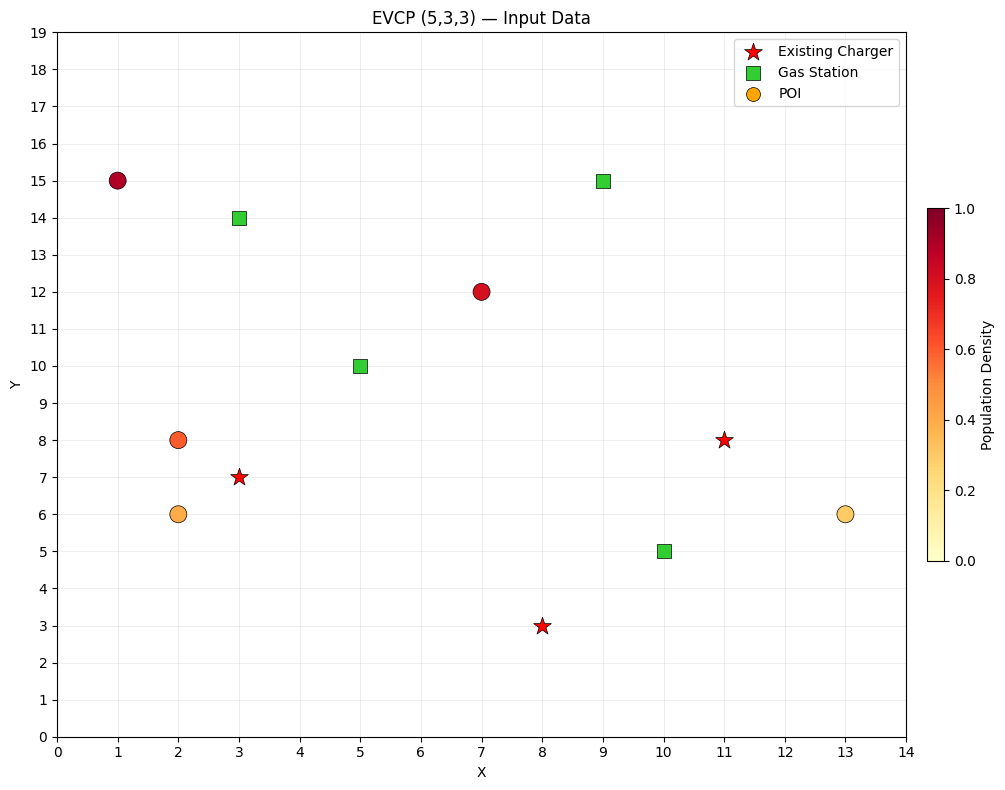

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# 1. Input data plot
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(11, 8))
sc = ax.scatter(
    [p[0] for p in points_of_interest],
    [p[1] for p in points_of_interest],
    c=[p[2] for p in points_of_interest],
    cmap=cm.YlOrRd, norm=mcolors.Normalize(vmin=0, vmax=1),
    s=150, zorder=5, edgecolors='black', linewidths=0.5
)
plt.colorbar(sc, ax=ax, pad=0.02, shrink=0.5, label='Population Density')
ex_x, ex_y = zip(*existing_charging_points)
ax.scatter(ex_x, ex_y, color='red', s=180, marker='*', zorder=5,
           edgecolors='black', linewidths=0.5, label='Existing Charger')
gs_x, gs_y = zip(*gas_stations)
ax.scatter(gs_x, gs_y, color='limegreen', s=100, marker='s', zorder=5,
           edgecolors='black', linewidths=0.5, label='Gas Station')
ax.scatter([], [], c='orange', s=100, edgecolors='black', linewidths=0.5, label='POI')
ax.set_xticks(range(0, 15))
ax.set_yticks(range(0, 20))
ax.grid(True, linewidth=0.5, alpha=0.3)
ax.set_xlabel('X'); ax.set_ylabel('Y')
ax.set_title('EVCP (5,3,3) — Input Data')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

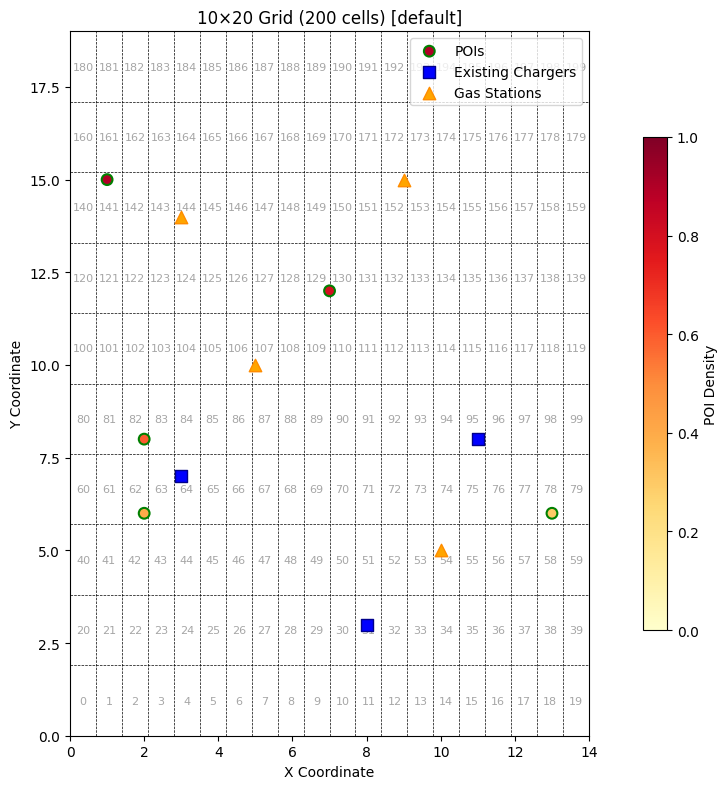

  Grid Info:
    Grid   31 (row=1, col=11): 1 charger(s)
    Grid   54 (row=2, col=14): 1 gas station(s)
    Grid   62 (row=3, col=2): 1 POI(s) [densities: 0.40]
    Grid   64 (row=3, col=4): 1 charger(s)
    Grid   78 (row=3, col=18): 1 POI(s) [densities: 0.30]
    Grid   82 (row=4, col=2): 1 POI(s) [densities: 0.60]
    Grid   95 (row=4, col=15): 1 charger(s)
    Grid  107 (row=5, col=7): 1 gas station(s)
    Grid  130 (row=6, col=10): 1 POI(s) [densities: 0.80]
    Grid  141 (row=7, col=1): 1 POI(s) [densities: 0.90]
    Grid  144 (row=7, col=4): 1 gas station(s)
    Grid  152 (row=7, col=12): 1 gas station(s)


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# 2. Grid discretization
# ─────────────────────────────────────────────────────────────────────────────

grid_details, plot_deets = divide_graph_into_parts(
    x_min=X_MIN, x_max=X_MAX, y_min=Y_MIN, y_max=Y_MAX,
    num_qubits=N_QUBITS,
    points_of_interest=points_of_interest,
    existing_chargers=existing_charging_points,
    gas_stations=gas_stations,
    grid_division="default",
    grid_details_flag=True,
)

CELL WEIGHT SUMMARY
------------------------  --------
Total cells               200
Cells with POIs           5 (2.5%)
Total aggregated density  3.00
Max weight                5.00
Min non-zero weight       1.67
Total gas stations        4
Total existing chargers   3
------------------------  --------

TOP 8 CELLS BY WEIGHT (Grid Data Table):
  Grid ID    Row    Col    # POIs    Raw    Norm    Weight    Gas Sta.    Chargers
---------  -----  -----  --------  -----  ------  --------  ----------  ----------
      141      7      1         1    0.9   1         5               0           0
      130      6     10         1    0.8   0.889     4.444           0           0
       82      4      2         1    0.6   0.667     3.333           0           0
       62      3      2         1    0.4   0.444     2.222           0           0
       78      3     18         1    0.3   0.333     1.667           0           0


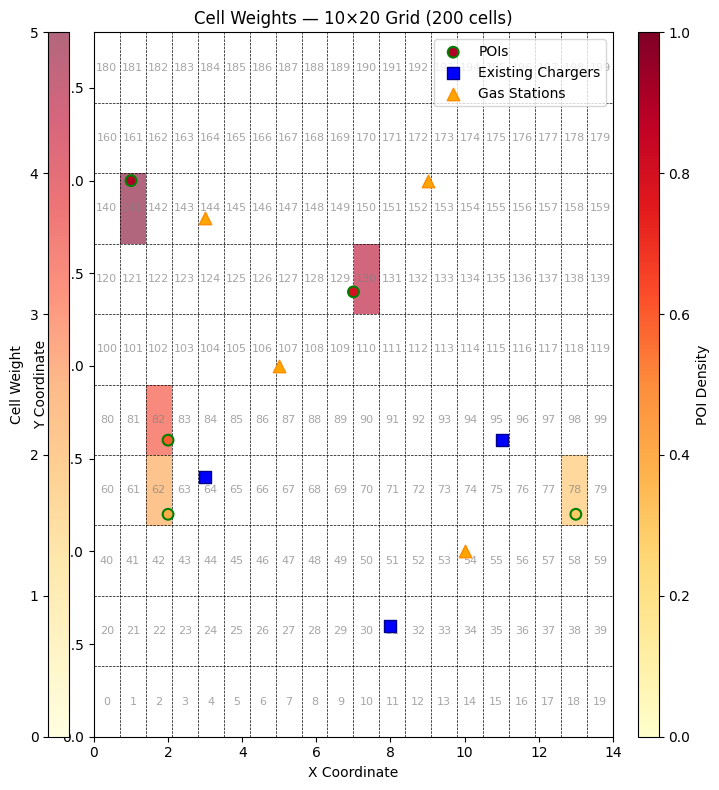

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# 3. Cell weight calculation
# ─────────────────────────────────────────────────────────────────────────────

cell_weights = calculate_cell_weights(
    grid_details, scale_factor=SCALE_FACTOR, min_weight=MIN_WEIGHT
)
print_weight_summary(cell_weights, grid_details, top_n=8)

plot_cell_weights(
    plot_deets, grid_details, cell_weights,
    points_of_interest=points_of_interest,
    existing_chargers=existing_charging_points,
    gas_stations=gas_stations,
    show_data_points=True, show_weight_values=False,
)

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# 4. Parameter suggestion (FA-002)
# ─────────────────────────────────────────────────────────────────────────────

params = suggest_parameters(grid_details, cell_weights, plot_deets, m=M)
print_parameter_suggestions(params)

r, a, t    = params['radii'], params['alpha'], params['intra']
lambda_val = params['lambda']

SUGGESTED PARAMETERS

Local Radii:
Radius                                      Value
----------------------------------------  -------
R₁  — H1 POI attraction radius                  4
Rₛ  — service gap radius (matches R₁)           4
R₃  — H3 existing charger penalty radius        1
R₄  — H4 new charger spacing radius             2
R₆  — H6 coverage redundancy radius             1

Objective Weights (α):
Parameter                                     Value
------------------------------------------  -------
α₁  — H1 POI attraction         [dominant]     3
α₂  — H2 gas station bonus                     0.5
α₃  — H3 existing charger penalty              1.65
α₄  — H4 new charger spacing                   1.5
α₅  — H5 constraint  (applied to λ)            1
α₆  — H6 coverage redundancy                   0.54

Intra-term Magnitudes:
Parameter                                  Value
---------------------------------------  -------
β  — gas station bonus magnitude               1
γ  — existin

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# 5. QUBO construction
# ─────────────────────────────────────────────────────────────────────────────

Q_obj, h5_params, diags = build_qubo(
    grid_details, cell_weights, plot_deets, m=M,
    alpha1=a['a1'], alpha2=a['a2'], alpha3=a['a3'],
    alpha4=a['a4'], alpha5=a['a5'], alpha6=a['a6'],
    beta=t['beta'], gamma=t['gamma'], delta=t['delta'], epsilon=t['epsilon'],
    lam=lambda_val,
    R1=r['R1'], Rs=r['Rs'], R3=r['R3'], R4=r['R4'], R6=r['R6'],
)

diag_count    = sum(1 for (i, j) in Q_obj if i == j)
offdiag_count = sum(1 for (i, j) in Q_obj if i != j)
diags['diag_entries']    = diag_count
diags['offdiag_entries'] = offdiag_count

In [8]:
good = [141, 62, 130]   # your best cells from before
bad  = [10, 11, 12]     # random low-density cells

for sol in [good, bad]:
    score = evaluate_solution(Q_obj, sol)
    diag_contribution = sum(Q_obj.get((i,i), 0.0) for i in sol)
    offdiag_contribution = score - diag_contribution
    print(f"{sol}: total={score:.3f}  diag={diag_contribution:.3f}  offdiag={offdiag_contribution:.3f}")

[141, 62, 130]: total=-7.797  diag=-7.797  offdiag=0.000
[10, 11, 12]: total=4.475  diag=2.475  offdiag=2.000


In [9]:
def plot_Q_matrix(Q_obj, N, title="Q_obj Matrix", clip_percentile=99):
    Q = np.zeros((N, N))
    for (i, j), val in Q_obj.items():
        Q[i, j] = val
        if i != j:
            Q[j, i] = val

    nonzero = Q[Q != 0]
    vmax = np.percentile(np.abs(nonzero), clip_percentile) if len(nonzero) > 0 else 1.0

    plt.figure(figsize=(8, 7))
    plt.imshow(Q, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    plt.colorbar(label=f'Q value (clipped at {clip_percentile}th pct ± {vmax:.2f})')
    plt.title(title)
    plt.xlabel('Cell j')
    plt.ylabel('Cell i')
    plt.tight_layout()
    plt.show()

    # Plot diagonal only
    diag = np.array([Q_obj.get((i,i), 0.0) for i in range(N)])
    plt.figure(figsize=(10, 2))
    plt.bar(range(N), diag, color=['blue' if v < 0 else 'red' for v in diag])
    plt.axhline(0, color='black', linewidth=0.5)
    plt.title("Diagonal of Q_obj (H1+H2+H3 per cell)")
    plt.xlabel("Cell ID")
    plt.ylabel("Q_ii value")
    plt.tight_layout()
    plt.show()

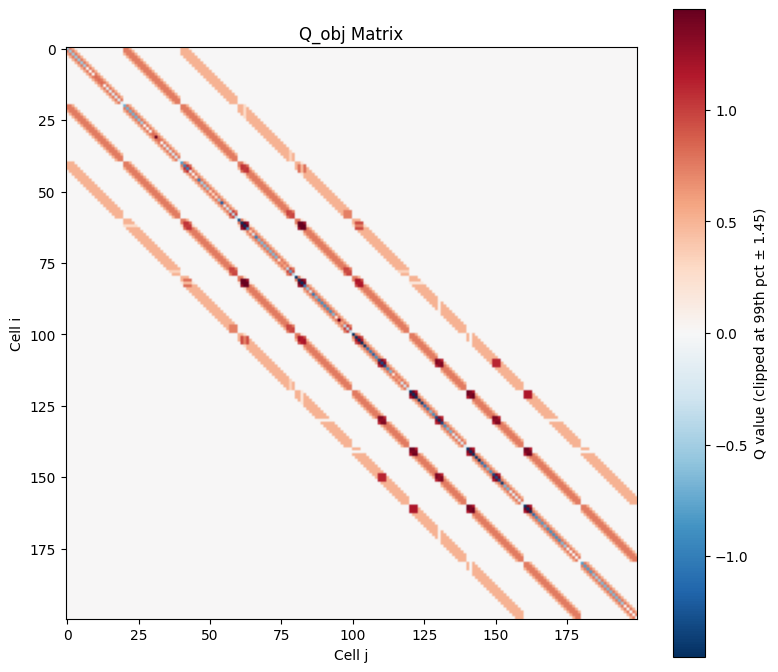

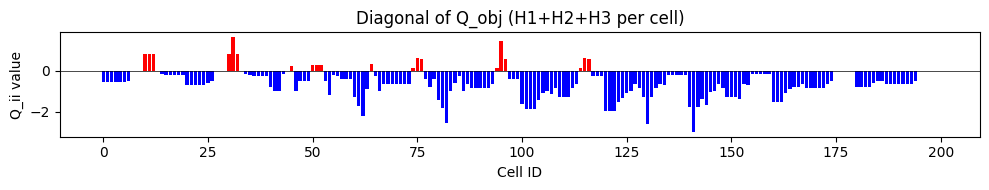

In [10]:
plot_Q_matrix(Q_obj, N_QUBITS)